In [77]:
import sys
sys.path.insert(0, '..')

In [78]:
# Basic imports
import jax.numpy as np
import jax.random as jr
import jax.scipy as jsp
import jax
import numpy

jax.config.update("jax_enable_x64", True)


# Optimisation imports
import zodiax as zdx
import optax
import optimistix as optx

# dLux imports
import dLux as dl
import dLux.utils as dlu

# Visualisation imports
from tqdm.auto import tqdm
import matplotlib.pyplot as plt
import matplotlib
import chainconsumer as cc


%matplotlib inline
plt.rcParams['image.cmap'] = 'inferno'
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = 'lower'
plt.rcParams['figure.dpi'] = 72
plt.rcParams["font.size"] = 24

from detectors import *
from apertures import *
from models import *
from stats import posterior
from fitting import *
from plotting import *
from spectra import *

import jax.tree_util as jtu
import interpax as ipx

def set_array(pytree):
    dtype = np.float64 if jax.config.x64_enabled else np.float32
    floats, other = eqx.partition(pytree, eqx.is_inexact_array_like)
    floats = jtu.tree_map(lambda x: np.array(x, dtype=dtype), floats)
    return eqx.combine(floats, other)

In [79]:
objs = [
    "HD-139664",
    "HD109085",
    "GJ784-PSF",
    "PSF-5-K0",
    "GSC8056-0482",
    "GSC8491-1194",
    "GSC8894-0426",
    "HIP10679",
    "HIP107947",
    "HIP109901",
    "HIP112312A",
    "HIP112312B",
    "HIP114530",
    "HIP118008",
    "HIP12413",
    "HIP12545",
    "HIP12787B",
    "HIP17695",
    "HIP18859",
    "HIP19335",
    "HIP1993",
    "HIP21547",
    "HIP21632",
    "HIP23309",
    "HIP26990",
    "HIP2729",
    "HIP36627",
    "HIP37766",
    "HIP39896B",
    "HIP41889",
    "HIP50156",
    "HIP56445",
    "HIP6485",
    "HIP77199",
    "HIP9892",
    "HIP9902",
    "SSS1102-34",
    "TWA12",
    "TWA23",
    "TYC5672-0216",
    "G238-44",
]

In [80]:
objs[34]

'HIP9892'

In [81]:
len(objs)

41

In [82]:
wid = 80
oversample = 4

nwavels = 20
npoly=5

n_modes = 15
n_zernikes = 30

resolved_wid = 1

optics = NICMOSCoronagraph(512, wid, oversample, n_modes=n_modes, n_zernikes=n_zernikes)

detector = NICMOSDetector(oversample, wid)

spectrum_basis = np.ones((nwavels, npoly))


ddir = '../data/NICMOS-LAPL-DD2/LAPL_DATA_DD2/comtemp_flats-DD2/'
# ddir = '../data/NICMOS-LAPL-DD1/archive.stsci.edu/missions/hlsp/laplace/dd1/LAPL/NICMOS-LAPL-DD1/LAPL_DATA/contemp_flats/repaired/'

flatdir = '../data/NICMOS-LAPL-DD2/LAPL_HOLEFLATS_DD2/'

vects = np.load("../data/iterative_spectrum_basis_F110W.npy")[:,:npoly]
assert vects.shape == (nwavels, npoly)
spectrum_basis = vects/np.sqrt(np.mean(vects**2, axis=0))

# extra_bad = np.full((wid,wid), False).at[30:50, 30:50].set(True)#.at[:, 35:45].set(True)


exposures_single = [
    exposure_from_file(ddir + 'n9pf21kkq_o_clc_calf.fits', SinglePointFit(spectrum_basis, "F110W"), crop=wid, extra_bad=None, flatcorr=flatdir),

    # exposure_from_file(ddir + 'n9gh23mgq_o_clc_calf.fits', SinglePointFit(spectrum_basis, "F160W"), crop=wid, extra_bad=None, flatcorr=flatdir),
    # exposure_from_file(ddir + 'n8zu85ndq_m_clc_calf.fits', SinglePointFit(spectrum_basis, "F160W"), crop=wid),
]


287.9589 5.4
Version 4.1.1
40.5699


ADCZERO                    0.0 / analog-digital conversion zero level (DN)       [astropy.io.fits.card]


In [83]:
exp = exposures_single[0]

In [84]:
np.nansum(exp.data)

Array(25941.77459231, dtype=float64)

In [85]:
exposures_single[0].hdr["ADCGAIN"]

5.4

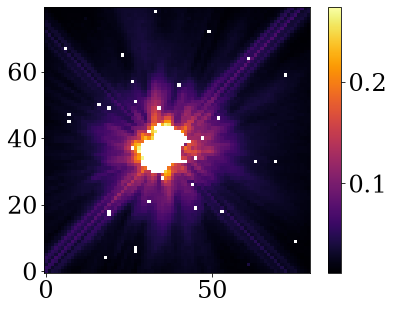

In [86]:
plt.imshow(np.sqrt(exp.data/(exp.hdr["ADCGAIN"]*exp.exptime)))
plt.colorbar()

In [87]:
exposures_single[0].exptime

287.9589

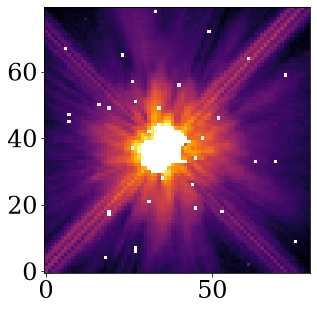

In [88]:
plt.imshow(exposures_single[0].data**0.125)

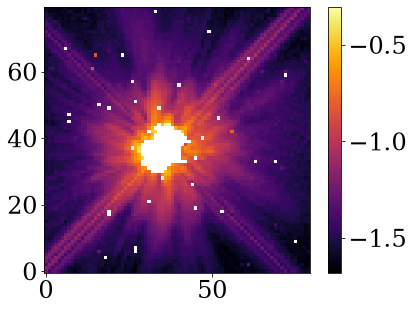

In [89]:
plt.imshow(np.log10(exposures_single[0].err))
plt.colorbar()

([], [])

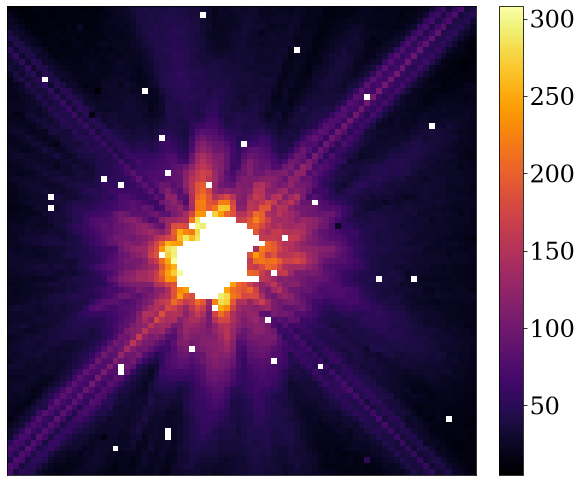

In [90]:
plt.figure(figsize=(8,8), layout="compressed")
plt.imshow(exposures_single[0].data/exposures_single[0].err)
plt.colorbar()
plt.xticks([])
plt.yticks([])

In [91]:
params = {
    "spectrum": {},
    "primary_opd": {},
    "primary_low": {},
    "primary_tilt": {},
    "cold_mask_opd": {},
    "cold_mask_tilt": {},
    "cold_mask_shift": {},
    "cold_mask_rot": {},
    "cold_mask_shear": {},
    "cold_mask_scale": {},
    "primary_rot": {},
    "primary_shear": {},

    "bias": {},
    "occulter_radius": 0.7,
    "occulter_coeffs": np.zeros(2)+1,
    "fnumber": 45.7,
    "anisotropy": 1.+1e-5,

    "outer_radius": 1.2*0.9768,
    "secondary_radius": 0.357*1.2,
    "spider_width": 0.072*1.2,
    "primary_spider": 0.0256,
}


for idx, exp in enumerate(exposures_single):
    params["spectrum"][exp.fit.get_key(exp, "spectrum")] = (np.zeros(npoly)).at[0].set((np.nansum(exp.data)/nwavels)*6)

    params["primary_tilt"][exp.fit.get_key(exp, "primary_tilt")] = np.array([-0.75, -0.05])*0.075
    # params["cold_mask_tilt"][exp.fit.get_key(exp, "cold_mask_tilt")] = np.array([-0.2167105 , -0.17420508])#*0.
    params["cold_mask_tilt"][exp.fit.get_key(exp, "cold_mask_tilt")] = np.array([
        # (np.array(exp.hdr["TARSIAFY"],dtype=float) - (256-44)),
        (np.array(exp.hdr["TARSIAFX"],dtype=float) - (256-181)), 
        (np.array(exp.hdr["TARSIAFY"],dtype=float) - (256-44))
    ])*0.075


    params["primary_opd"][exp.fit.get_key(exp, "primary_opd")] = np.zeros((n_modes, n_modes))
    params["primary_low"][exp.fit.get_key(exp, "primary_low")] = np.zeros((n_zernikes))
    params["cold_mask_opd"][exp.fit.get_key(exp, "cold_mask_opd")] = np.zeros(16).at[0].set(120.)#np.array([120.])

    params["cold_mask_shift"][exp.fit.get_key(exp, "cold_mask_shift")] = np.array([13.,10.]) #np.asarray([-13.,-7.])#
    params["cold_mask_rot"][exp.fit.get_key(exp, "cold_mask_rot")] = 2.5#-90.
    params["primary_rot"][exp.fit.get_key(exp, "primary_rot")] = -0.6##-90.
    params["cold_mask_scale"][exp.fit.get_key(exp, "cold_mask_scale")] = np.asarray([1.,1.])
    params["cold_mask_shear"][exp.fit.get_key(exp, "cold_mask_shear")] = np.asarray([0.06,-0.06])
    params["primary_shear"][exp.fit.get_key(exp, "primary_shear")] = np.asarray([0.,0.])

    params["bias"][exp.fit.get_key(exp, "bias")] = 0.
    

model_single = set_array(NICMOSModel(exposures_single, params, optics, detector))

params = ModelParams(params)

26.226957179207613


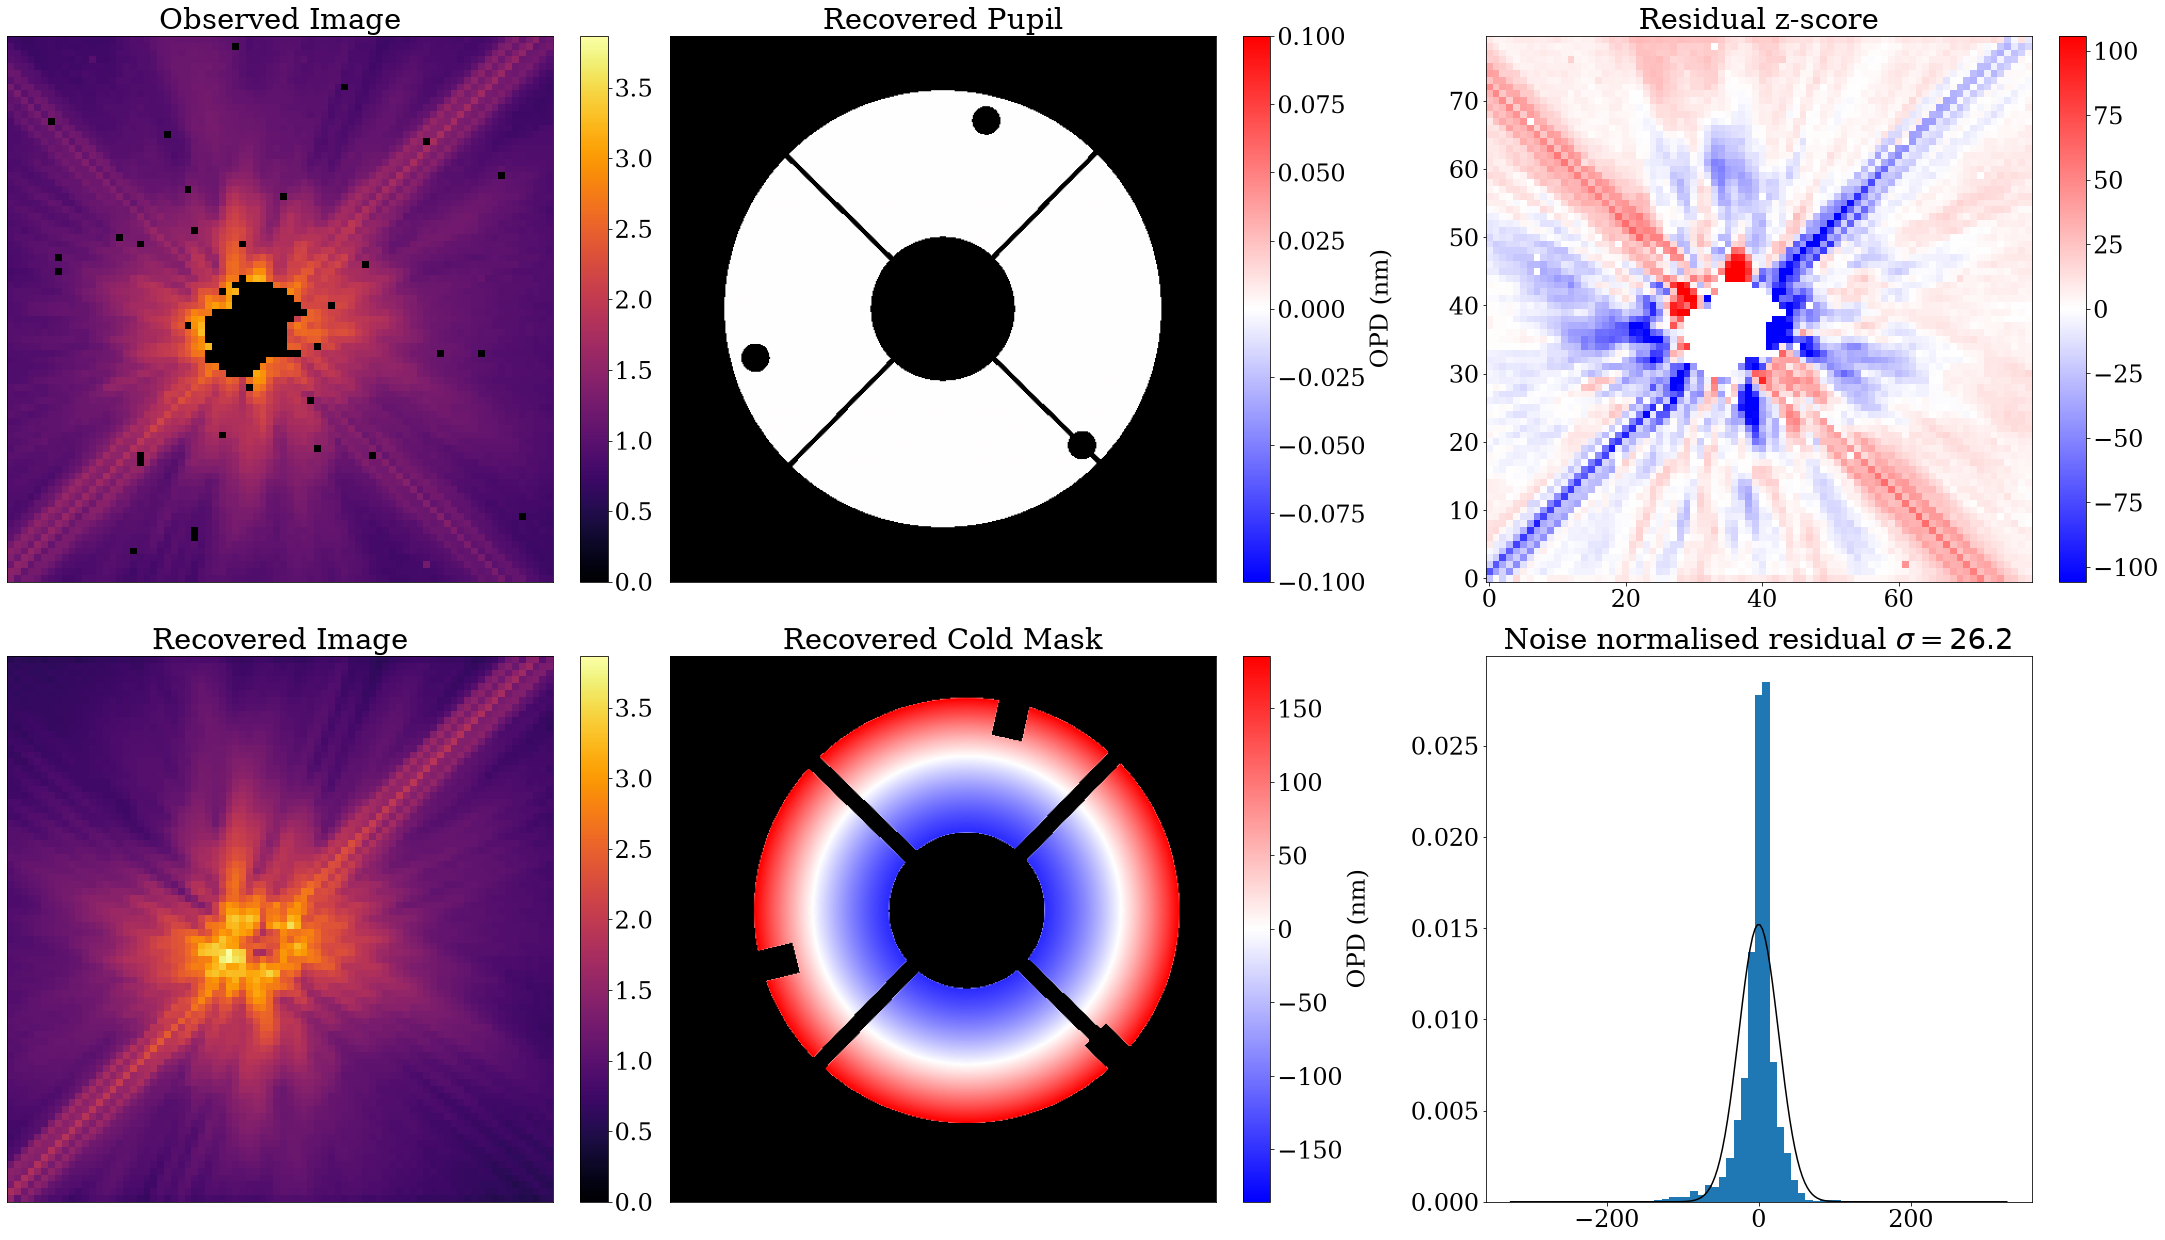

In [92]:
plot_comparison(model_single, params, exposures_single, percentile=99, wf_size=512)

In [93]:
print(-(exp.hdr["TARSIAFX"]-(256-181)), exp.hdr["TARSIAFY"]-(256-41))

3.2734999999999985 -5.864000000000004


In [ ]:
def sgd(lr, delay, momentum=0.5):
    return optax.sgd(zdx.optimisation.delay(lr, delay), momentum=momentum)

def adam(lr, delay):
    return optax.adam(zdx.optimisation.delay(lr, delay))


g = 5e-2

"""
    "spectrum": sgd(g*3, 0),
    "cold_mask_shift": sgd(g*20, 40),
    
    "bias": sgd(g*3, 20),
    "primary_opd": sgd(g*0.1, 10),
    # "primary_opd": adam(0.1, 10),

    "cold_mask_opd": sgd(g*3, 10),

    "primary_tilt": sgd(g*1, 10),
    "cold_mask_tilt": sgd(g*1, 10),
    #"jitter": opt(g*1, 120),


    "cold_mask_shear": sgd(g*2, 200),
    "cold_mask_rot": sgd(g*3, 200),
    "cold_mask_scale": sgd(g*15, 200),

    # "quadrature": sgd(g*20, 400)

    "occulter_radius": sgd(g*10, 200),
    "fnumber": sgd(g*0.05, 220),

    "occulter_coeffs": sgd(g*20, 300),
"""

things = {
    "primary_opd": sgd(g*2, 0),

    "spectrum": sgd(g*1, 0),
    "primary_tilt": sgd(g*1., 0),
    "cold_mask_tilt": sgd(g*1, 0),
    "cold_mask_opd": sgd(g*1., 0),

    "bias": sgd(g*3, 0),
    "cold_mask_shift": sgd(g*1, 0),
    "cold_mask_rot": sgd(g*5., 50),
    "primary_rot": sgd(g*3., 0),

    "primary_low": sgd(g*1, 0),

    "cold_mask_scale": sgd(g*1, 0),
    "cold_mask_shear": sgd(g*1, 0),

    "primary_shear": sgd(g*1, 0),
    # "primary_shear": sgd(g*5, 100),

    "occulter_radius": sgd(g*1., 0),
    "occulter_coeffs": sgd(g*1, 0),

    "secondary_radius": sgd(g*1., 0),
    "spider_width": sgd(g*1., 0),
    "primary_spider": sgd(g*1., 0),

    "fnumber": sgd(g*1., 0),
    "anisotropy": sgd(g*1., 0),


}

things_start = {
    "spectrum": sgd(g*3, 30.),
    "primary_tilt": sgd(g*3., 15.),
    "cold_mask_tilt": sgd(g*0.3, 0),
    "cold_mask_opd": sgd(g*1., 40),

    # "bias": sgd(g*3, 50),
    # "cold_mask_shift": sgd(g*10., 70),
    # "cold_mask_rot": sgd(g*3., 85),
    # "primary_rot": sgd(g*20., 85),

    # "primary_low": sgd(g*0.05, 150),

    # "cold_mask_scale": sgd(g*5, 100),
    # "cold_mask_shear": sgd(g*10, 100),

    # "primary_shear": sgd(g*5, 100),
    # # "primary_shear": sgd(g*5, 100),

    # "occulter_radius": sgd(g*1., 120),
    # "occulter_coeffs": sgd(g*1, 120),

    # # "outer_radius": sgd(g*1., 120),
    # "secondary_radius": sgd(g*1., 120),
    # "spider_width": sgd(g*1., 120),
    # "primary_spider": sgd(g*1., 120),

    # "fnumber": sgd(g*1., 200),
    # "anisotropy": sgd(g*2., 200),
}

groups = list(things.keys())

In [95]:
orig_params = params.params
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things_start})

In [96]:
losses, params_history = optimise_new(
    opt_params, model_single, exposures_single, things_start, 200,
    precond_method="gn_exact", precond_kwargs=dict(chunk=16))

  0%|          | 0/200 [00:00<?, ?it/s]

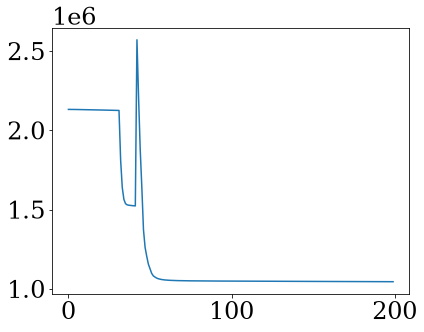

In [97]:
plt.plot(losses[:])

4
17.58151070577168


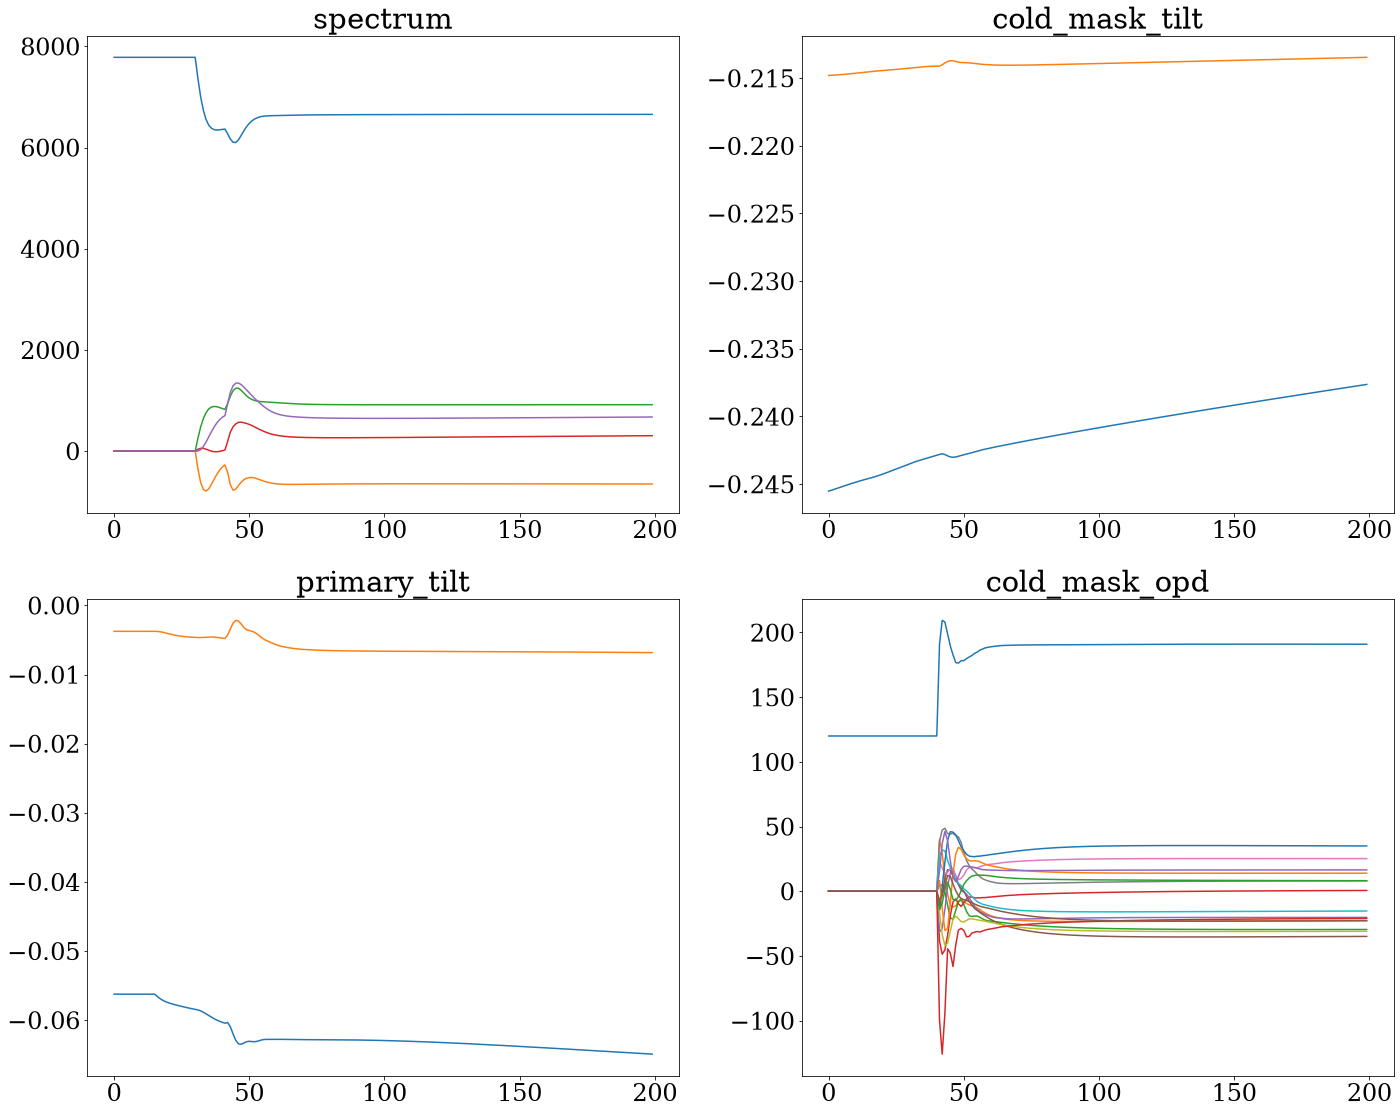

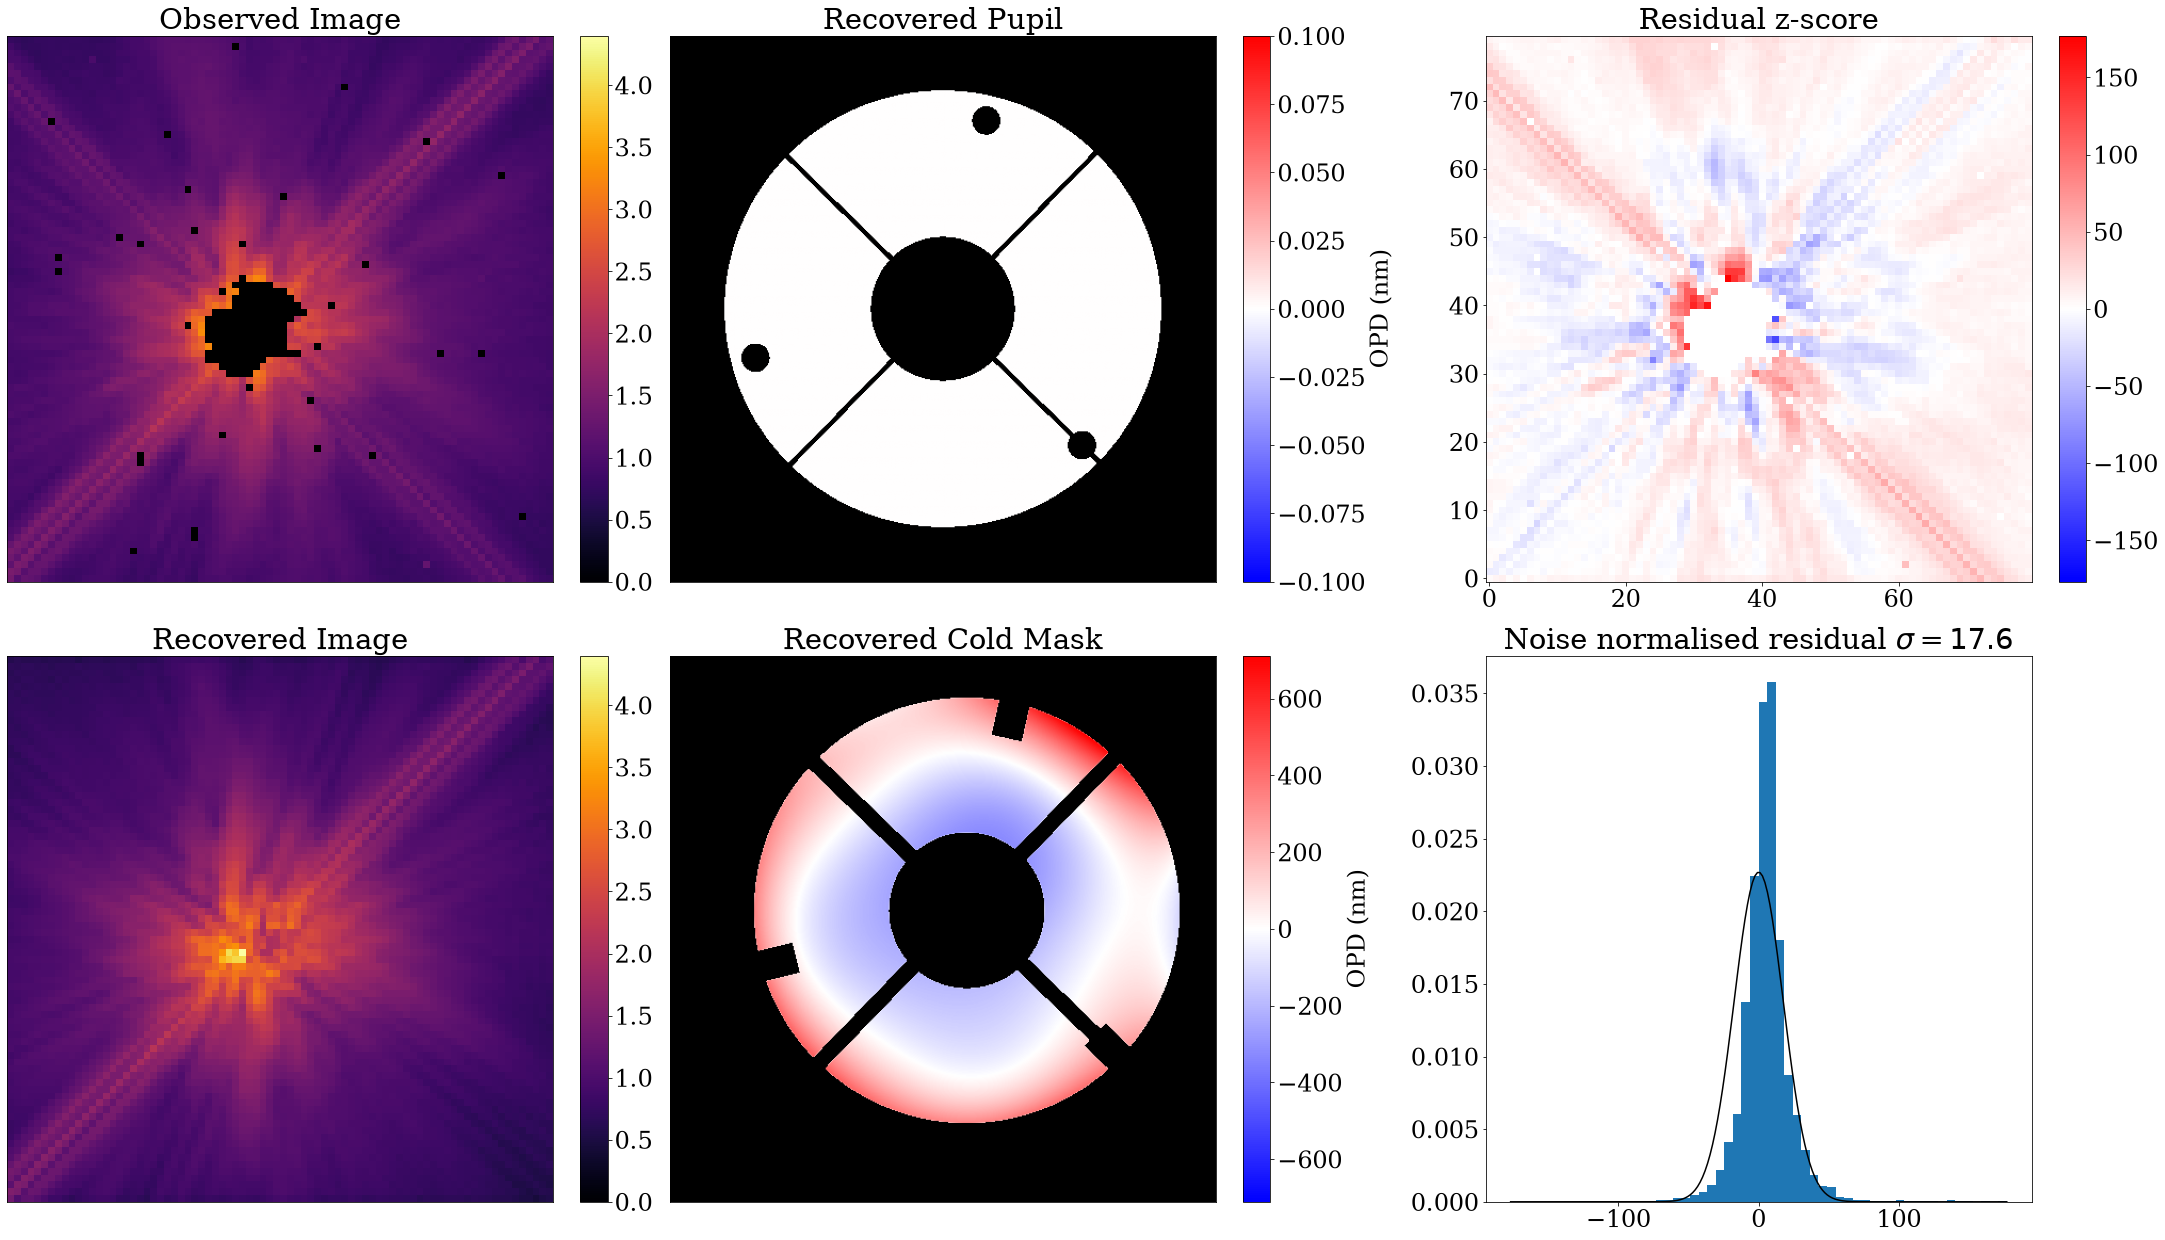

In [98]:
plot_params(params_history, list(things_start.keys()), xw = 2)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, percentile=100, quadrature=False, wf_size=512)

In [99]:
stop

NameError: name 'stop' is not defined

In [ ]:
final_model = ModelParams(params_history[-1]).inject(model_single)
final_optics = exposures_single[0].fit.update_optics(final_model, exposures_single[0])

In [ ]:
dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)

Wavefront(
  phasor=c128[128,128], wavelength=f64[], pixel_scale=f64[], center=f64[1]
)

In [ ]:
dlu.arcsec2rad(0.3)*24*2.4

8.37758040957278e-05

In [ ]:
testocculter = dl.CircularAperture(dlu.arcsec2rad(0.3)*24*2.4)

In [ ]:
# testocculter = CLIMBOcculter(dlu.arcsec2rad(0.3)*24*2.4, np.zeros(1)+3e-3, np.zeros(1))
final_optics.occulter.layers["occulter"]

CLIMBOcculter(r=f64[], cc=f64[1], ss=f64[1], normalise=False)

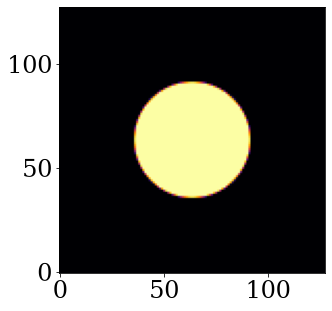

In [ ]:
plt.imshow(np.abs(testocculter(dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor))

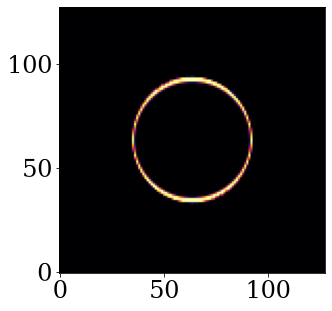

In [ ]:
plt.imshow(np.abs(final_optics.occulter.layers["occulter"](dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor)- np.abs(testocculter(dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor))

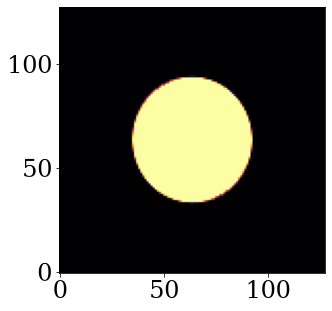

In [ ]:
plt.imshow(np.abs(final_optics.occulter.layers["occulter"](dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor))

In [ ]:
params_history[-1]

{'anisotropy': Array(0.98762028, dtype=float64),
 'bias': {'n8zu85ncq': Array(0.23630256, dtype=float64)},
 'cold_mask_opd': {'global': Array([147.86752521, -52.36284549, -53.80858765, -10.1267686 ,
         -22.40385396,  12.82756378,  11.91153469,   7.20774991,
         -31.0176146 ,  -9.88861319,  18.85047397,  21.90937947,
          -8.26071518,  11.48898124,  13.21918398,  -1.97353194],      dtype=float64)},
 'cold_mask_rot': {'global': Array(2.88486757, dtype=float64)},
 'cold_mask_scale': {'global': Array([0.99775636, 0.99097741], dtype=float64)},
 'cold_mask_shear': {'global': Array([ 0.04069814, -0.05895292], dtype=float64)},
 'cold_mask_shift': {'global': Array([12.23687121,  8.06323574], dtype=float64)},
 'cold_mask_tilt': {'global': Array([-0.12978178, -0.19708977], dtype=float64)},
 'fnumber': Array(45.29703424, dtype=float64),
 'occulter_coeffs': Array([-0.42977308, 20.7585538 ], dtype=float64),
 'occulter_radius': Array(0.72991239, dtype=float64),
 'primary_low': {'n8zu8

In [ ]:
orig_params = params.params | params_history[-1]
opt_params = set_array({k:orig_params[k] for k in orig_params if k in things})

In [ ]:
losses, params_history = optimise_new(
    opt_params, model_single, exposures_single, things, 3000,
    precond_method="gn_probe", precond_kwargs=dict(n_probes=32))

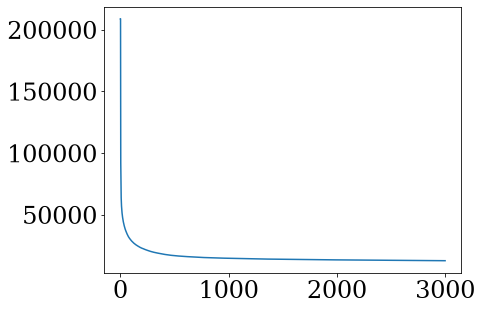

In [ ]:
plt.plot(losses[:])

In [ ]:
losses[-1]

Array(12797.21825467, dtype=float64)

19
2.788128136628893


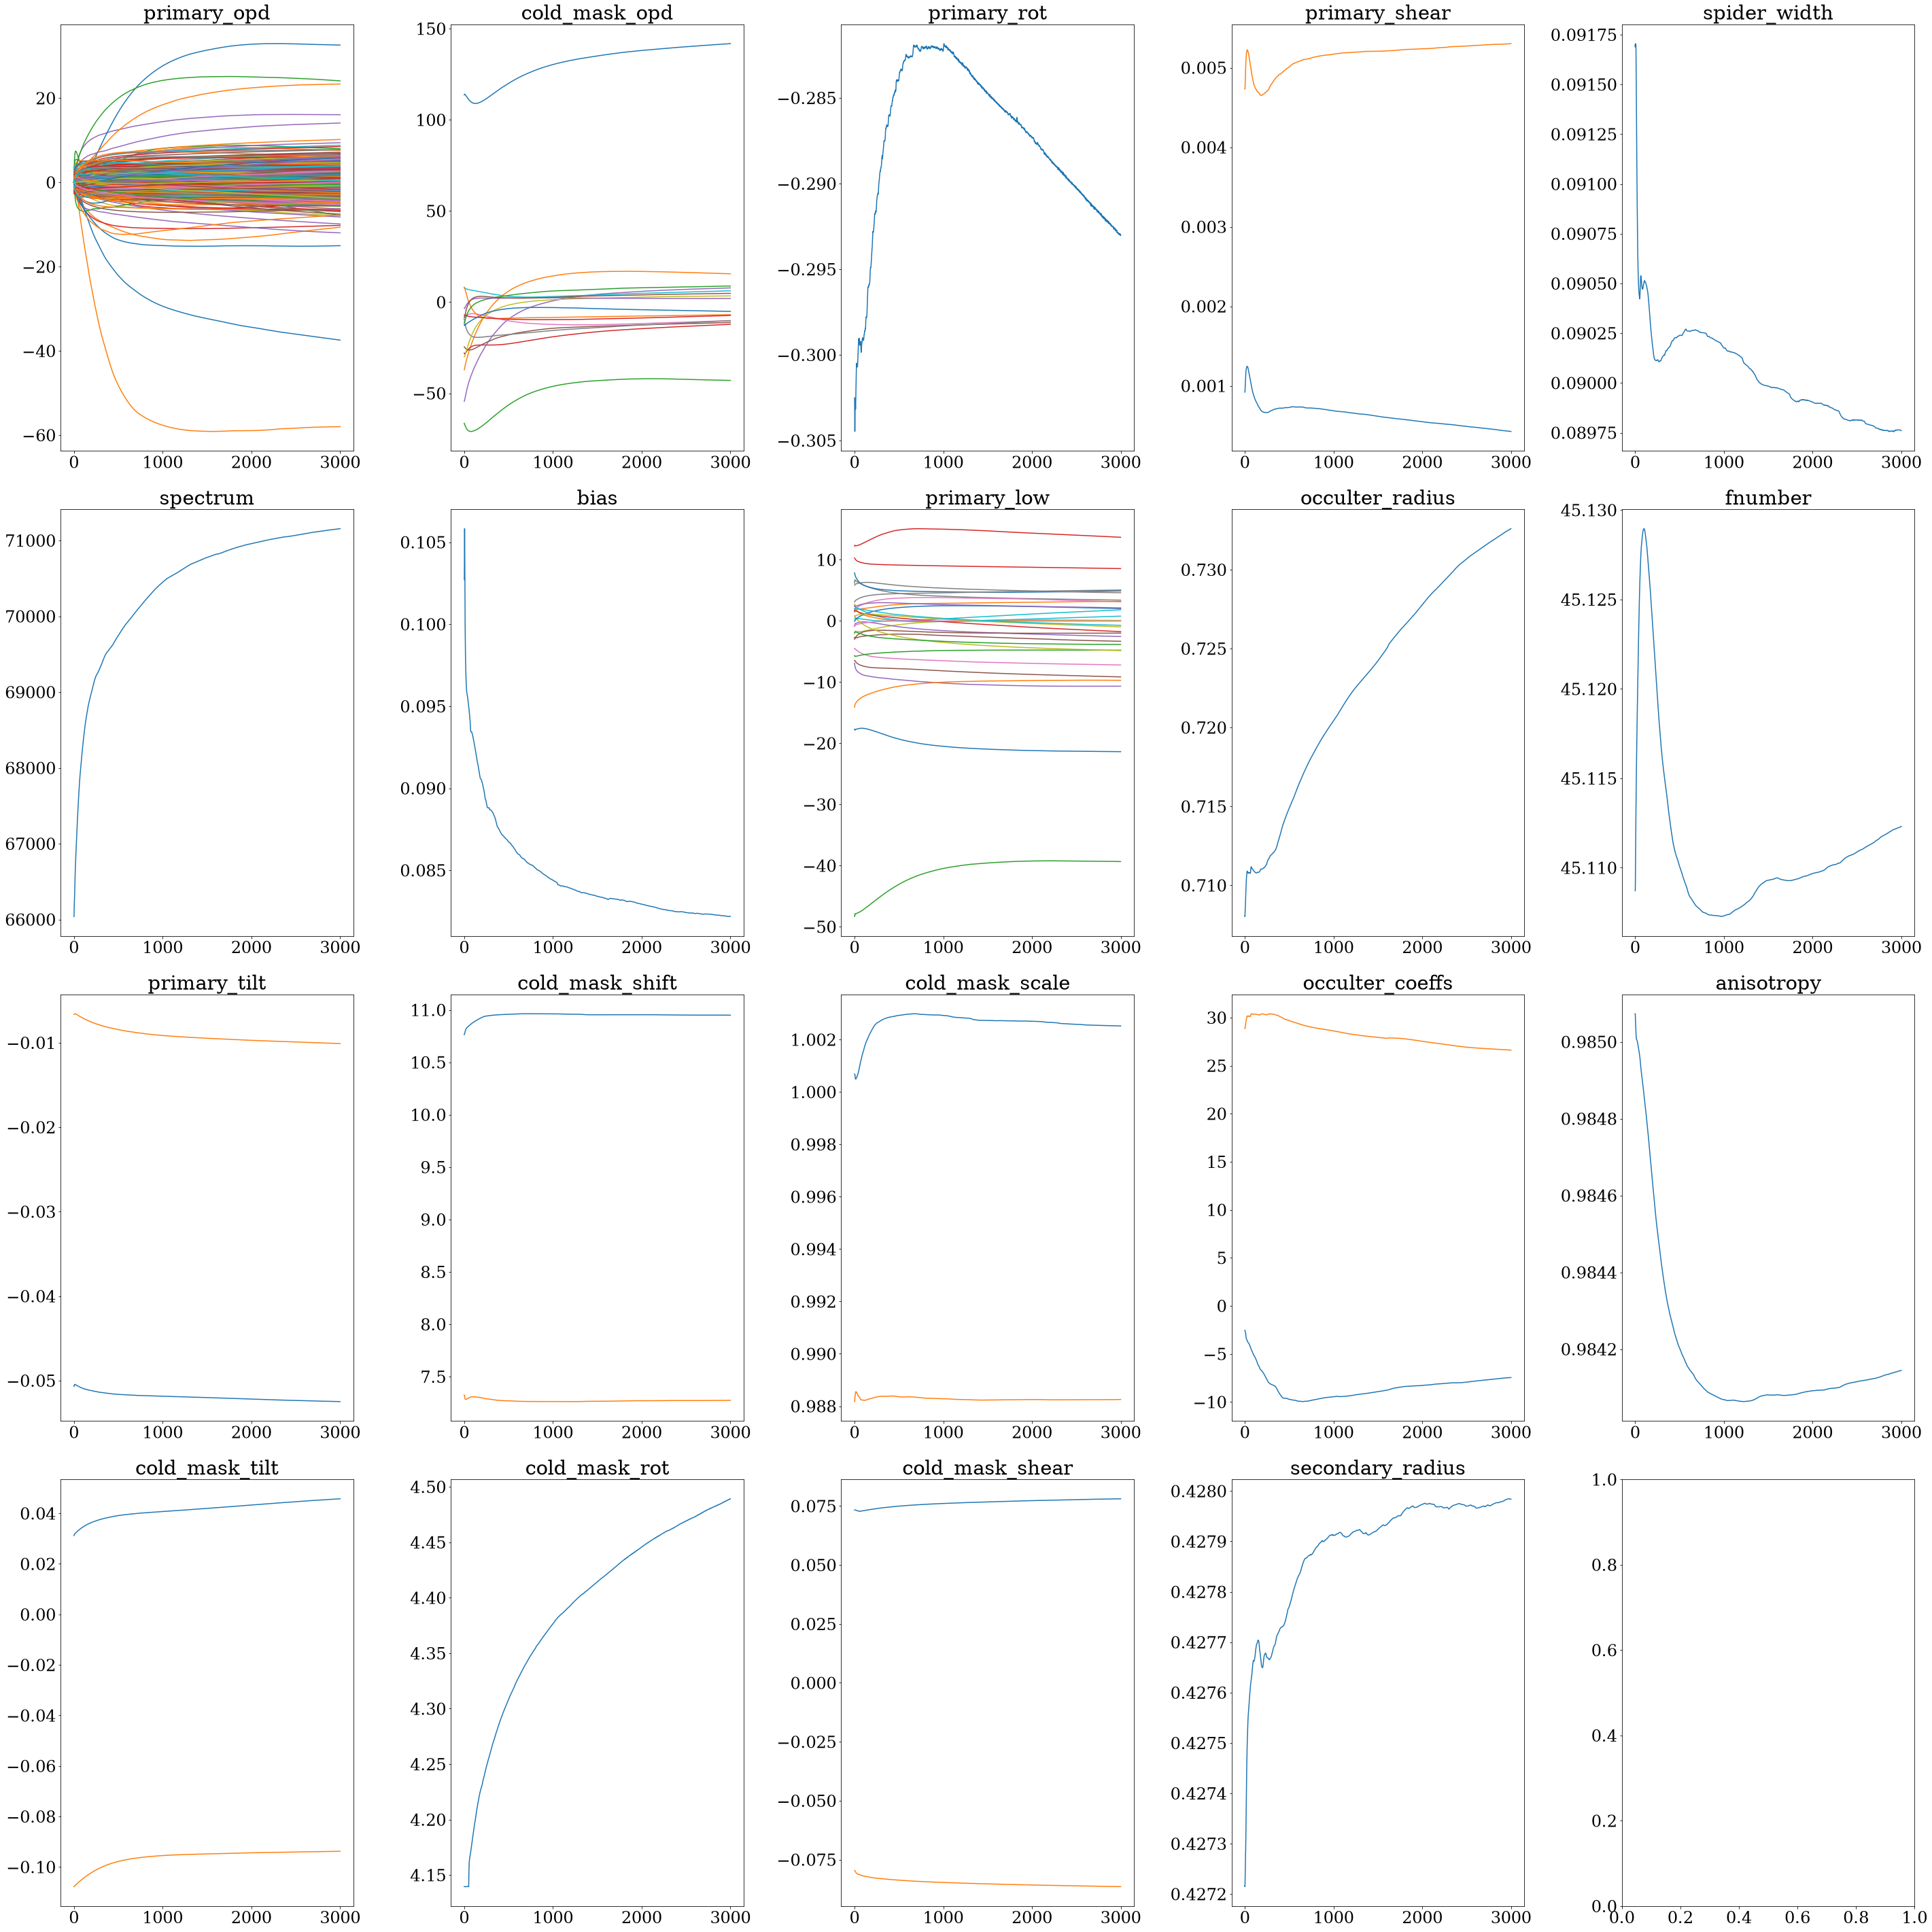

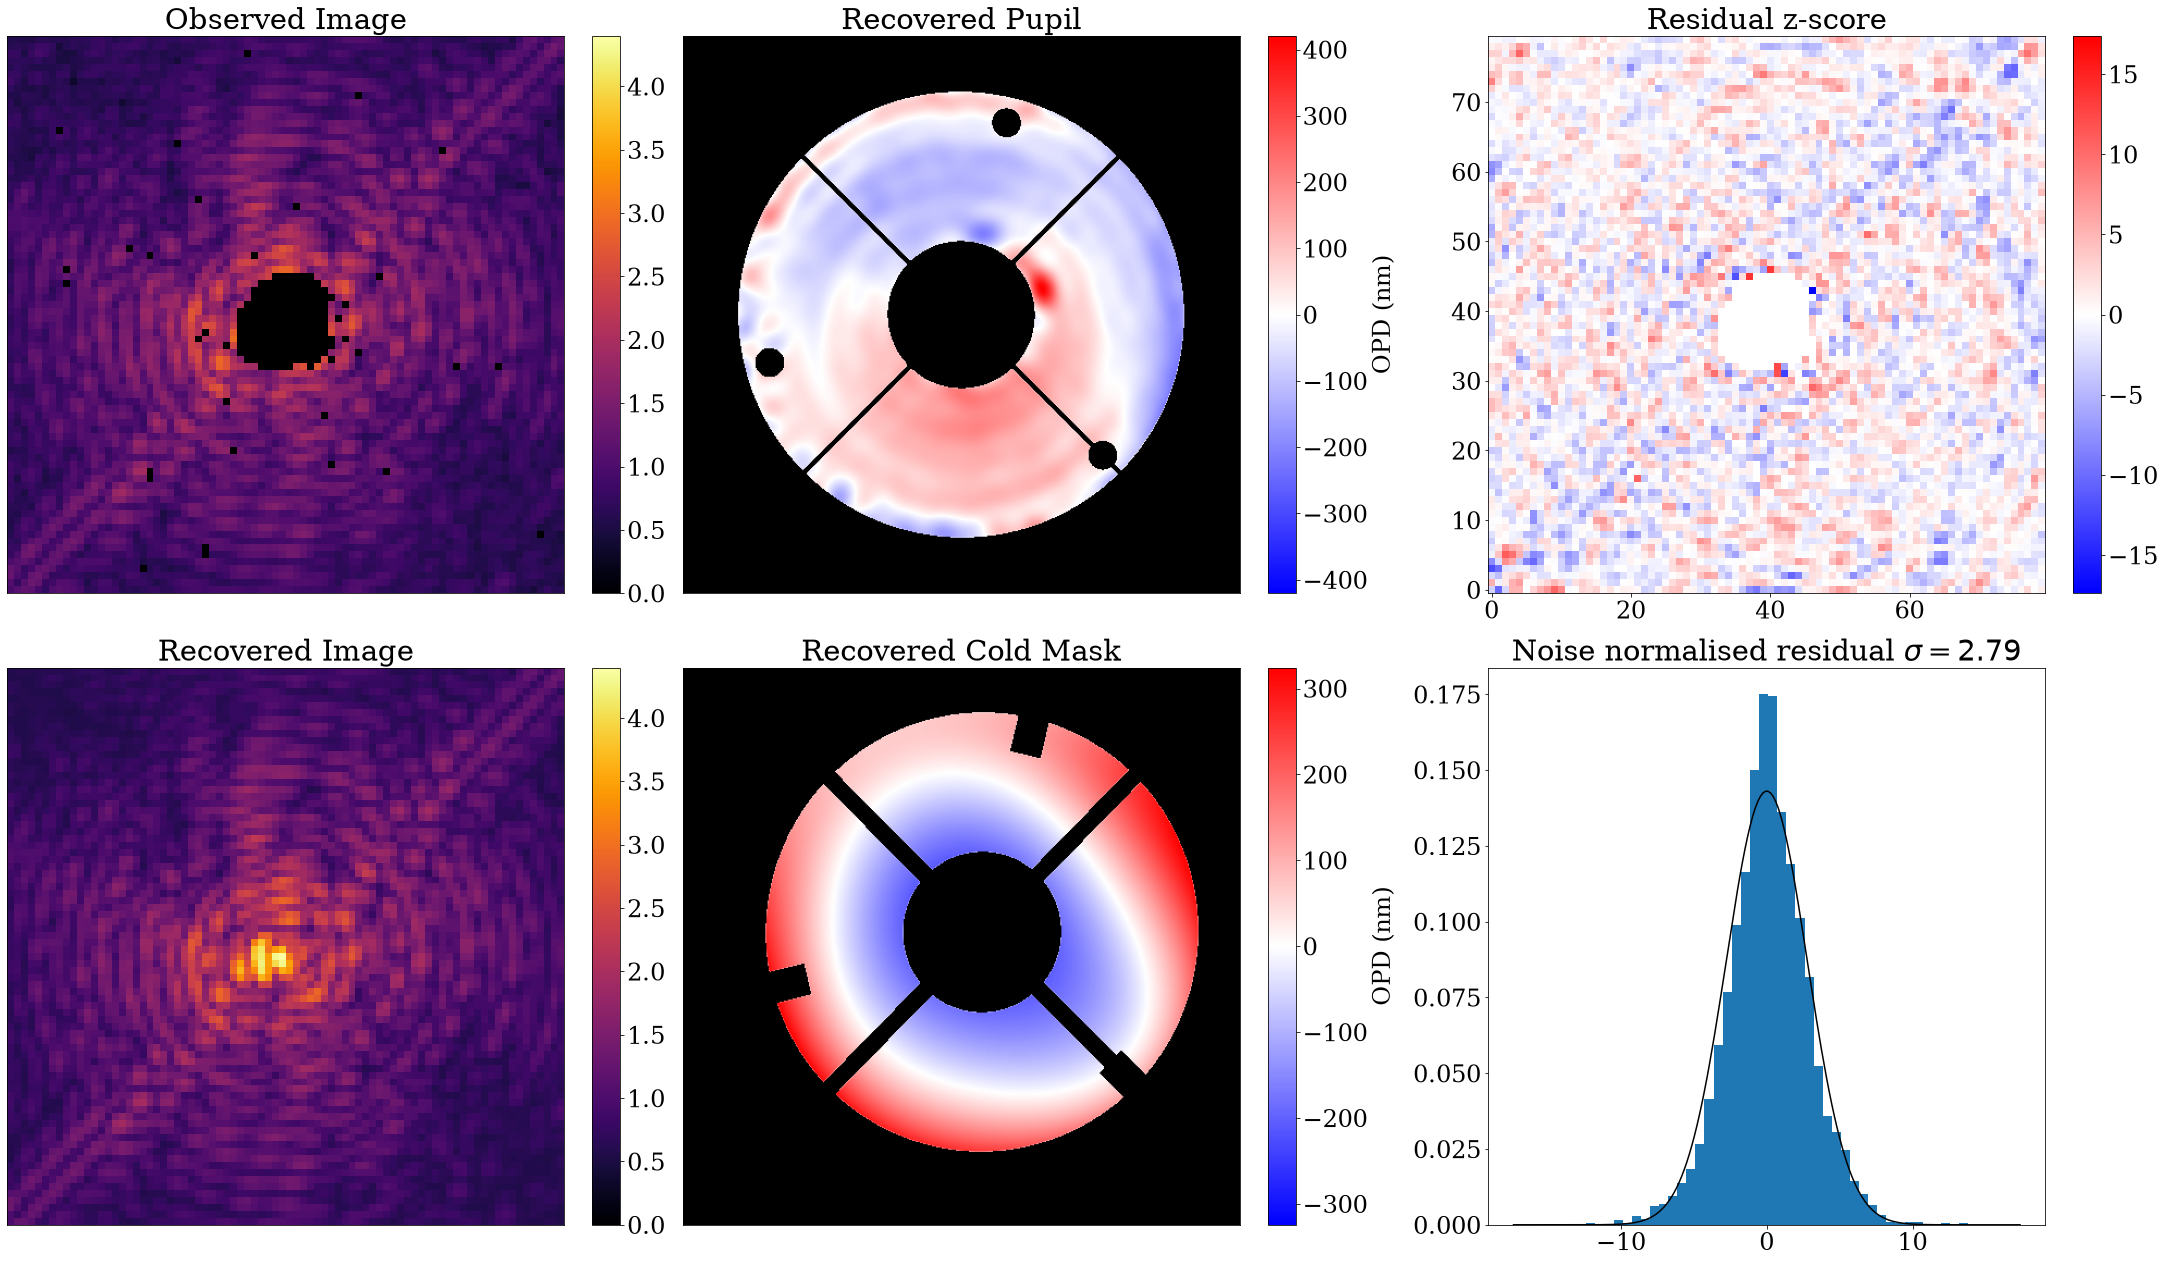

In [ ]:
plot_params(params_history, groups, xw = 4)
plot_comparison(model_single, ModelParams(params_history[-1]), exposures_single, quadrature=False)

In [ ]:
np.sqrt(3**2 * 100)

Array(30., dtype=float64, weak_type=True)

In [ ]:
params_history[-1]

{'anisotropy': Array(0.98414451, dtype=float64),
 'bias': {'n8jv51u6q': Array(0.08219047, dtype=float64)},
 'cold_mask_opd': {'global': Array([141.77043628,  15.54282654, -42.93509985, -12.19314724,
           7.78426998, -11.17774929, -10.18025204, -10.14114404,
           3.41314833,   6.21010674,  -5.09097741,  -6.86823805,
           8.84011064,  -7.31434242,   1.97501028,   4.81462106],      dtype=float64)},
 'cold_mask_rot': {'global': Array(4.48919657, dtype=float64)},
 'cold_mask_scale': {'global': Array([1.00252102, 0.98825766], dtype=float64)},
 'cold_mask_shear': {'global': Array([ 0.078087  , -0.08645904], dtype=float64)},
 'cold_mask_shift': {'global': Array([10.94950784,  7.27372597], dtype=float64)},
 'cold_mask_tilt': {'global': Array([ 0.04576892, -0.09378882], dtype=float64)},
 'fnumber': Array(45.11231086, dtype=float64),
 'occulter_coeffs': Array([-7.45864086, 26.61657015], dtype=float64),
 'occulter_radius': Array(0.73259809, dtype=float64),
 'primary_low': {'n8jv5

In [ ]:
np.save("params.npy", params_history[-1])

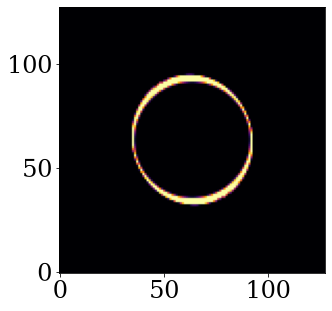

In [ ]:
final_model = ModelParams(params_history[-1]).inject(model_single)
final_optics = exposures_single[0].fit.update_optics(final_model, exposures_single[0])
testocculter = dl.CircularAperture(dlu.arcsec2rad(0.3)*24*2.4)

plt.imshow(np.abs(final_optics.occulter.layers["occulter"](dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor)- np.abs(testocculter(dl.Wavefront(1e-6, pixel_scale=3e-6, npixels=128)).phasor))